In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
!pip install openpyxl


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
df=pd.read_excel("C:/Users/Admin/Downloads/archive (2)/Online Retail.xlsx")


In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
df.shape

(541909, 8)

In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [10]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [11]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [12]:
#all none description
df[df['Description'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom


In [13]:
df=df.dropna(subset=["Description"])

In [14]:
df=df.dropna(subset=["CustomerID"])

In [15]:
#remove the row where description and customer are nan
df["Description"].isnull().sum()
df["CustomerID"].isnull().sum()

np.int64(0)

In [16]:
df.shape

(406829, 8)

In [17]:
#finding duplicates in rows
df.duplicated().sum()

np.int64(5225)

In [18]:
#find the total sales
df["Totalsales"]=df["Quantity"]*df["UnitPrice"]

In [19]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Totalsales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [20]:
df[["Quantity","UnitPrice","Totalsales"]].head()

,Quantity,UnitPrice,Totalsales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [21]:
df["Month"]=df["InvoiceDate"].dt.to_period("M")	
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Totalsales,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011-12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011-12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12


In [22]:
#monthly sales
monthlysales=df.groupby('Month')['Totalsales'].sum()
monthlysales

Month
2010-12     554604.020
2011-01     475074.380
2011-02     436546.150
2011-03     579964.610
2011-04     426047.851
2011-05     648251.080
2011-06     608013.160
2011-07     574238.481
2011-08     616368.000
2011-09     931440.372
2011-10     974603.590
2011-11    1132407.740
2011-12     342506.380
Freq: M, Name: Totalsales, dtype: float64

In [36]:
#topsales product
topsales=df.groupby("Description")["Totalsales"].sum()
topsales.head(10)

Description
4 PURPLE FLOCK DINNER CANDLES       270.76
50'S CHRISTMAS GIFT BAG LARGE      2269.75
DOLLY GIRL BEAKER                  2750.75
I LOVE LONDON MINI BACKPACK        1454.00
I LOVE LONDON MINI RUCKSACK           4.15
NINE DRAWER OFFICE TIDY             792.85
OVAL WALL MIRROR DIAMANTE          1010.20
RED SPOT GIFT BAG LARGE            2041.00
SET 2 TEA TOWELS I LOVE LONDON     7183.55
SPACEBOY BABY GIFT SET             6963.80
Name: Totalsales, dtype: float64

In [38]:
#sort rnage
topsaled_product=df.groupby("Description")["Totalsales"].sum().sort_values(ascending=False)
topsaled_product.head(10)

Description
REGENCY CAKESTAND 3 TIER              132870.40
WHITE HANGING HEART T-LIGHT HOLDER     93823.85
JUMBO BAG RED RETROSPOT                83236.76
PARTY BUNTING                          67687.53
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56499.22
RABBIT NIGHT LIGHT                     51137.80
CHILLI LIGHTS                          45936.81
PAPER CHAIN KIT 50'S CHRISTMAS         41500.48
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: Totalsales, dtype: float64

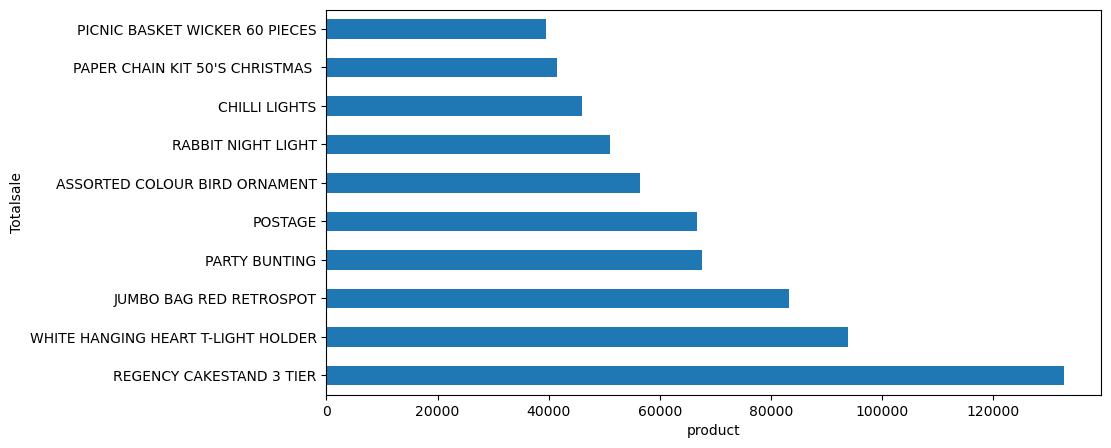

In [47]:
topsaled_product.head(10).plot(kind='barh',figsize=(10,5))
plt.xlabel("product")
plt.ylabel("Totalsale")

plt.show()

In [48]:
#top product quantity which is sold
top_quantity=df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)
top_quantity.head(10)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53215
JUMBO BAG RED RETROSPOT               45066
ASSORTED COLOUR BIRD ORNAMENT         35314
WHITE HANGING HEART T-LIGHT HOLDER    34147
PACK OF 72 RETROSPOT CAKE CASES       33409
POPCORN HOLDER                        30504
RABBIT NIGHT LIGHT                    27094
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25321
PACK OF 60 PINK PAISLEY CAKE CASES    24163
Name: Quantity, dtype: int64

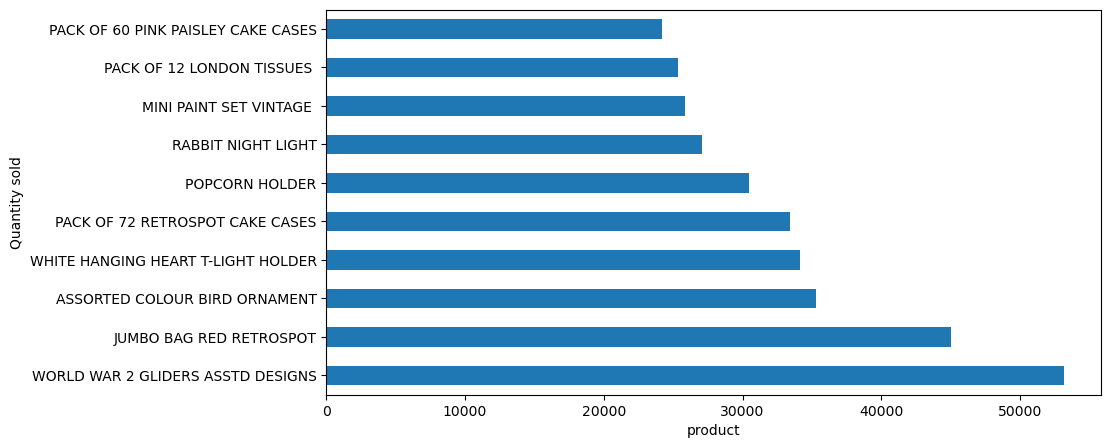

In [51]:
top_quantity.head(10).plot(kind='barh',figsize=(10,5))
plt.xlabel("product")
plt.ylabel("Quantity sold")
plt.show()

In [49]:
#highest product sold country wise 
top_country_Sales=df.groupby("Country")["Totalsales"].sum().sort_values(ascending=False)
top_country_Sales.head(10)

Country
United Kingdom    6767873.394
Netherlands        284661.540
EIRE               250285.220
Germany            221698.210
France             196712.840
Australia          137077.270
Switzerland         55739.400
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Totalsales, dtype: float64

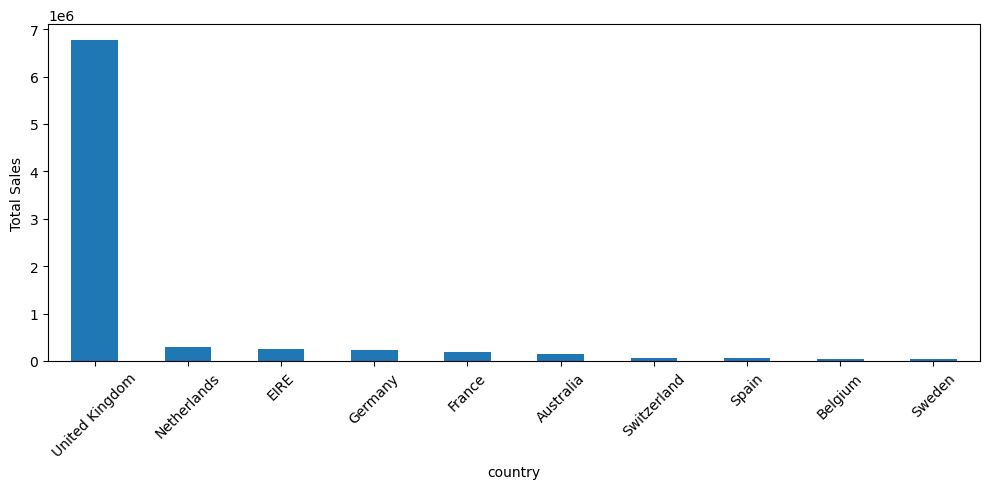

In [34]:
top_country_Sales.head(10).plot(kind="bar",figsize=(10,5))
plt.xlabel("country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
#average unit price by product
avg_price=df.groupby("Description")["UnitPrice"].mean().sort_values(ascending=False)
avg_price.head(10)

Description
DOTCOM POSTAGE                        744.147500
PICNIC BASKET WICKER 60 PIECES        649.500000
CRUK Commission                       495.839375
Manual                                334.425634
REGENCY MIRROR WITH SHUTTERS          156.428571
RUSTIC  SEVENTEEN DRAWER SIDEBOARD    156.034483
VINTAGE RED KITCHEN CABINET           150.663043
VINTAGE BLUE KITCHEN CABINET          143.653846
CHEST NATURAL WOOD 20 DRAWERS         118.076923
LOVE SEAT ANTIQUE WHITE METAL         115.388889
Name: UnitPrice, dtype: float64

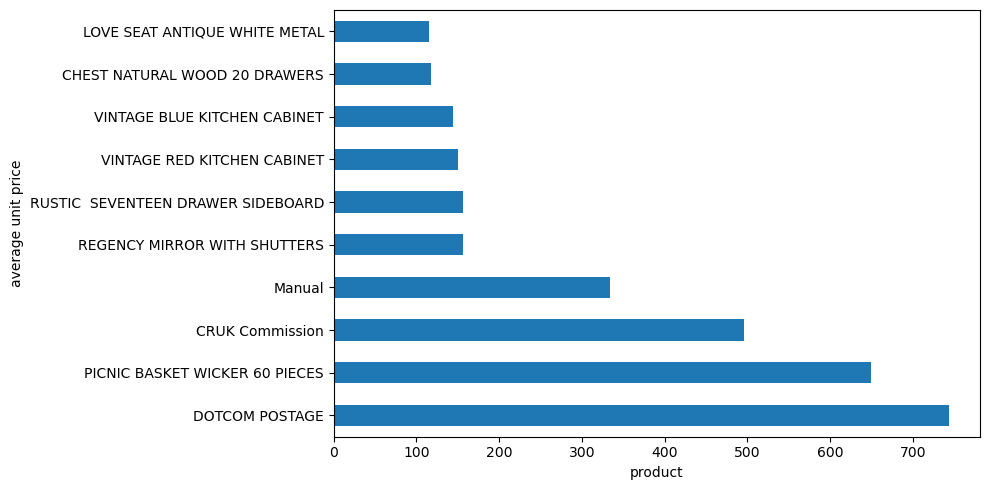

In [59]:
avg_price.head(10).plot(kind='barh',figsize=(10,5))
plt.xlabel("product")
plt.ylabel("average unit price")
plt.tight_layout()
plt.show()

# product analysis Insight
* The top_selling products by total sales were (REGENCY CAKESTAND 3 TIER).
* The products with the highest quantity sold were(WORLD WAR 2)
* The products with the highest average unit price were (DOTCOM POSTAGE)

In [63]:
#TOP CUSTOMER
top_customer=df.groupby("CustomerID")["Totalsales"].sum().sort_values(ascending=False)
top_customer

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187482.17
14911.0    132572.62
12415.0    123725.45
             ...    
12503.0     -1126.00
17603.0     -1165.30
14213.0     -1192.20
15369.0     -1592.49
17448.0     -4287.63
Name: Totalsales, Length: 4372, dtype: float64

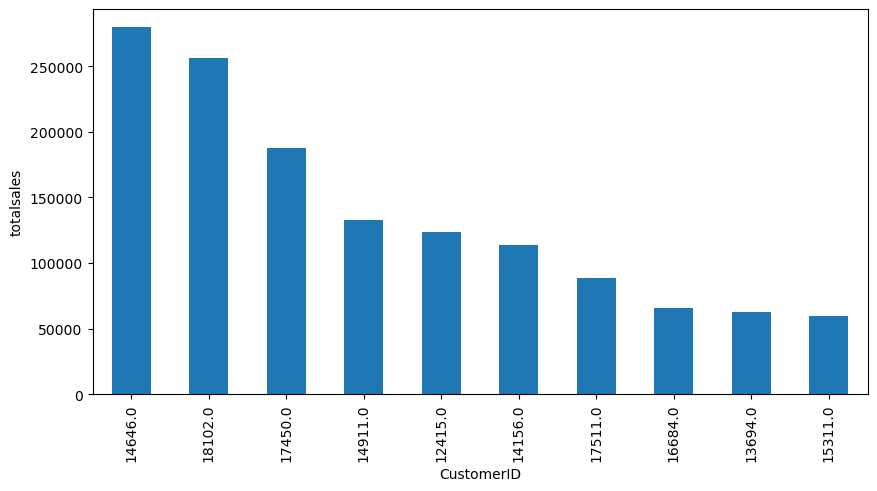

In [67]:
top_customer.head(10).plot(kind='bar',figsize=(10,5))
plt.xlabel("CustomerID")
plt.ylabel("totalsales")

plt.show()

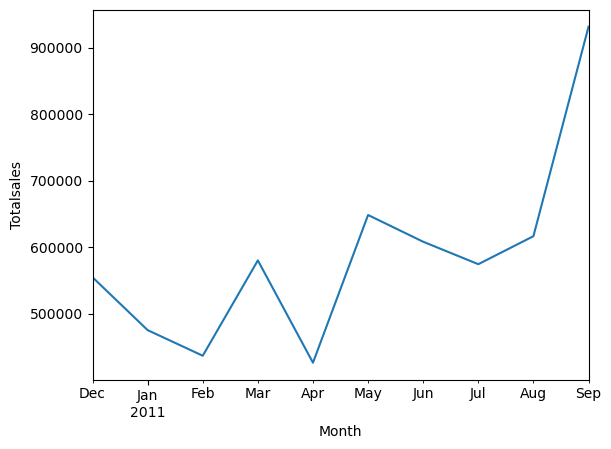

In [70]:
#monthly  sales trend
#graph beacause i already month column prepraed 
monthlysales.head(10).plot(kind='line')
plt.xlabel("Month")
plt.ylabel("Totalsales")
plt.show()               
                           

### The Online Retail dataset was analyzed using python,pandas,Numpy,Matplolib and seaborn. The project involved:-
* Data cleaning
* feature preparation
* sales analysis
* product analysis
* customer analysis
* country-wise analysis
  
The analysis helped identify sales trends,top-selling products, high-values customers and major contributing countries.